# Univariate Analysis

Univariate analysis is the simplest form of data analysis where we analyze a **single variable at a time**.

Our goals:
1. Understand the distribution and frequency of categorical features
2. Understand the central tendency, dispersion, and spread of numerical features
3. Detect anomalies, skewness, and potential outliers
4. Follow the **Theory → Code → Plot → Interpretation** pattern throughout

---


## 1. Setup & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Load Titanic dataset
df = pd.read_csv('../../data/titanic.csv')

# Preview shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. Categorical Univariate Analysis

Categorical variables represent labels or groups (e.g., `Sex`, `Pclass`, `Embarked`, `Survived`).
We start by assessing how observations are distributed across these categories.


### 2.1 Frequency Distribution (`value_counts`)

A frequency distribution counts how many occurrences exist for each unique category.
Adding `normalize=True` computes the relative proportions (percentages).


In [2]:
# Value counts for Embarkation Port
embarked_counts = df['Embarked'].value_counts(dropna=False)
embarked_percent = df['Embarked'].value_counts(normalize=True, dropna=False) * 100

pd.DataFrame({
    'Port': embarked_counts.index.fillna('Missing'),
    'Passenger Count': embarked_counts.values,
    'Percentage (%)': embarked_percent.values.round(2)
})


,Port,Passenger Count,Percentage (%)
0,S,644,72.28
1,C,168,18.86
2,Q,77,8.64
3,Missing,2,0.22


### Observation
- **`S` (Southampton)** is by far the largest embarkation port, accounting for **72.28%** of passengers (644 people).
- **`C` (Cherbourg)** accounts for **18.86%** (168 people).
- **`Q` (Queenstown)** accounts for **8.64%** (77 people).
- 2 passengers have missing (`NaN`) embarkation data.


### 2.2 Count Plot (`sns.countplot`)

A count plot uses vertical or horizontal bars to display the frequency of each category.
It makes category size comparisons immediately clear to the human eye.


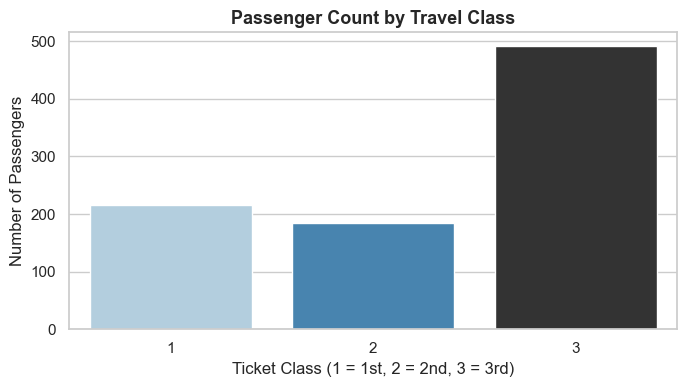

In [3]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df, 
    x='Pclass', 
    palette='Blues_d', 
    hue='Pclass', 
    legend=False
)

plt.title('Passenger Count by Travel Class', fontsize=13, weight='bold')
plt.xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Number of Passengers')
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/univariate_countplot_pclass.png', dpi=150)
plt.show()


### Observation
Third class was substantially larger than First and Second class combined. Over 490 passengers were in 3rd class, whereas 1st class had 216 and 2nd class had 184.


### 2.3 Bar Chart of Proportions

While count plots show raw totals, a bar chart can display normalized percentages to communicate proportions cleanly.


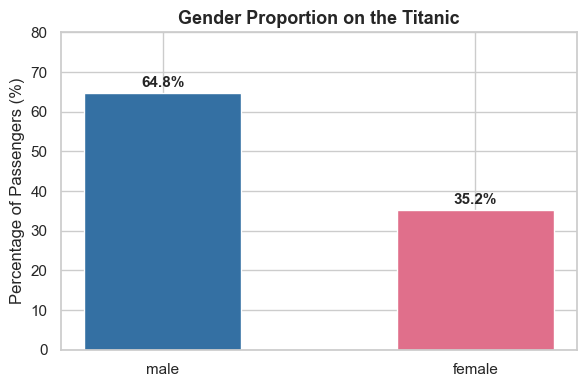

In [4]:
# Calculate percentage per gender
gender_pct = df['Sex'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(gender_pct.index, gender_pct.values, color=['#3470a3', '#e06f8b'], width=0.5)

plt.title('Gender Proportion on the Titanic', fontsize=13, weight='bold')
plt.ylabel('Percentage of Passengers (%)')
plt.ylim(0, 80)

# Add exact percentage text above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", ha='center', weight='bold')

plt.tight_layout()
plt.show()


### Observation
Males constituted **64.8%** of the passengers on board, while females accounted for **35.2%**.


### 2.4 Pie Chart & Donut Chart

A **Pie Chart** shows portions of a 100% whole as circular slices.
A **Donut Chart** places a hollow circle in the center. This helps because human perception is better at judging linear arc lengths than angular slice areas.


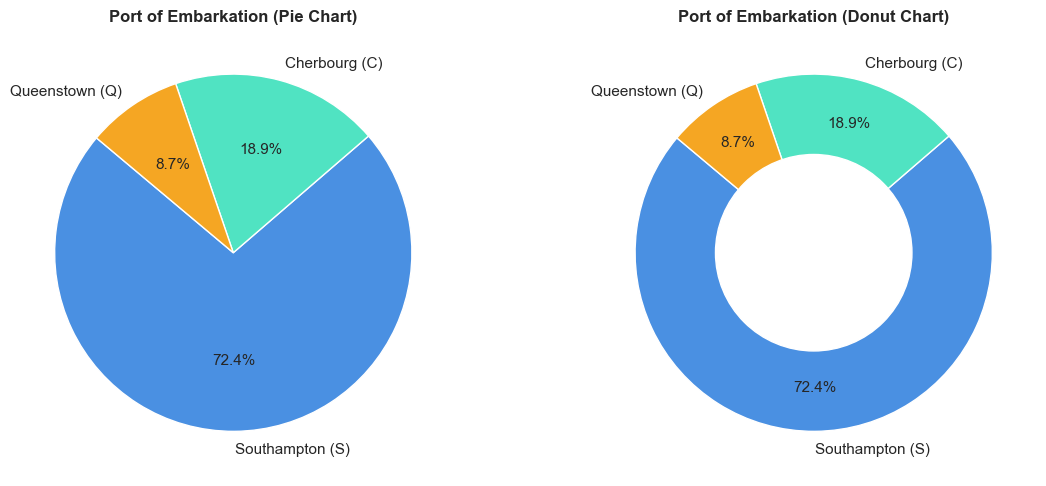

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4A90E2', '#50E3C2', '#F5A623']
labels = ['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)']
values = df['Embarked'].dropna().value_counts()

# Pie Chart
ax1.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
ax1.set_title('Port of Embarkation (Pie Chart)', fontsize=12, weight='bold')

# Donut Chart
wedges, texts, autotexts = ax2.pie(
    values, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.75
)

# Draw white center circle to create donut
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Port of Embarkation (Donut Chart)', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()


### Observation
Both charts illustrate that Southampton accounts for ~72% of passengers. Donut charts are generally preferred over pie charts in modern dashboards because the hollow center reduces perceptual distortion.


### 2.5 Pareto Chart (80/20 Rule)

A **Pareto Chart** combines a descending bar chart of individual frequencies with an ascending line chart of cumulative percentage.
It helps verify whether the **Pareto Principle** (e.g., 80% of outcomes stem from 20% of causes) applies.


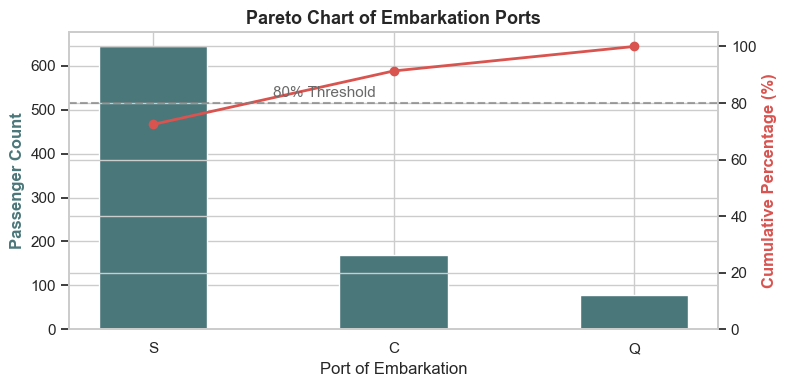

In [6]:
# Compute frequency and cumulative percentage for Embarked ports
pareto_df = df['Embarked'].value_counts().reset_index()
pareto_df.columns = ['Port', 'Count']
pareto_df['Cumulative_Pct'] = (pareto_df['Count'].cumsum() / pareto_df['Count'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(8, 4))

# Bar chart of individual counts
ax1.bar(pareto_df['Port'], pareto_df['Count'], color='#4a777a', width=0.45)
ax1.set_ylabel('Passenger Count', color='#4a777a', weight='bold')
ax1.set_xlabel('Port of Embarkation')

# Secondary axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(pareto_df['Port'], pareto_df['Cumulative_Pct'], color='#d9534f', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='#d9534f', weight='bold')
ax2.set_ylim(0, 105)

# Add reference line at 80%
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)
ax2.text(0.5, 82, '80% Threshold', color='dimgray')

plt.title('Pareto Chart of Embarkation Ports', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


### Observation
The first two ports (Southampton and Cherbourg) collectively account for over **91%** of all passengers, demonstrating heavy concentration.


## 3. Numerical Univariate Analysis

Numerical variables represent measurable quantities:
- **Discrete:** Countable integers (e.g., `SibSp` = 0, 1, 2, 3)
- **Continuous:** Any value along an interval (e.g., `Age`, `Fare`)


### 3.1 Discrete vs. Continuous Numerical Variables

Let us look at the unique values of `SibSp` (discrete) vs `Age` (continuous).


In [7]:
# Discrete feature inspection
print("Unique SibSp (Discrete family counts):", sorted(df['SibSp'].unique()))

# Continuous feature range
print(f"Age range (Continuous): {df['Age'].min():.2f} to {df['Age'].max():.2f} years")


Unique SibSp (Discrete family counts): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8)]
Age range (Continuous): 0.42 to 80.00 years


### 3.2 Histograms & The Effect of Bins

A histogram divides continuous data into non-overlapping intervals (bins) and counts points per bin.
**Bin size matters greatly:**
- Too few bins: Oversimplifies and hides multiple peaks (modes).
- Too many bins: Introduces noisy fluctuations.


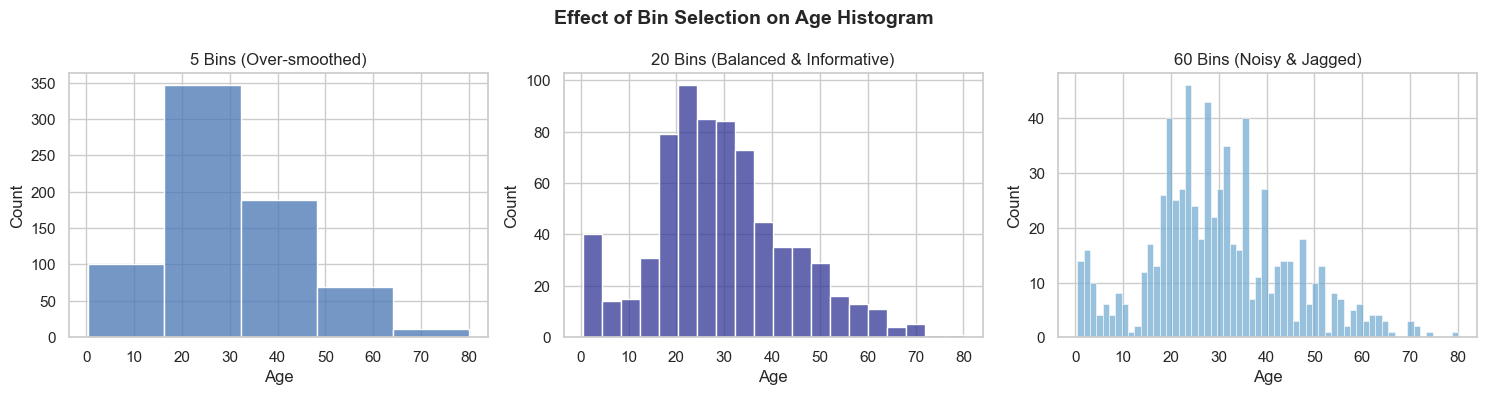

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Under-binned (5 bins)
sns.histplot(df['Age'], bins=5, ax=axes[0], color='#4575b4')
axes[0].set_title('5 Bins (Over-smoothed)')

# Balanced (20 bins)
sns.histplot(df['Age'], bins=20, ax=axes[1], color='#313695')
axes[1].set_title('20 Bins (Balanced & Informative)')

# Over-binned (60 bins)
sns.histplot(df['Age'], bins=60, ax=axes[2], color='#74add1')
axes[2].set_title('60 Bins (Noisy & Jagged)')

plt.suptitle('Effect of Bin Selection on Age Histogram', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


### Observation
- 5 bins conceals the subtle peak around toddlers and children.
- 20 bins cleanly reveals the unimodal peak between ages 20 and 30, along with a secondary bump under age 5.
- 60 bins is fragmented with lots of empty slots.


### 3.3 Kernel Density Estimation (KDE)

KDE provides a smooth continuous curve estimating the probability density function (PDF).
Unlike histograms, it does not depend on arbitrary bin edge placements.


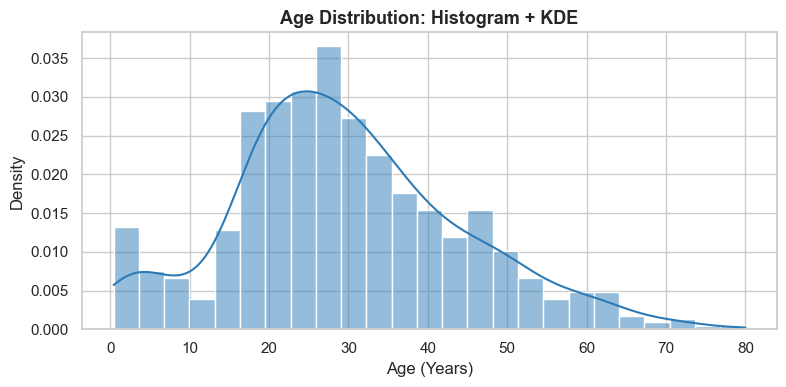

In [9]:
plt.figure(figsize=(8, 4))

# Combined Histogram and KDE
sns.histplot(df['Age'], kde=True, bins=25, color='#2c7bb6', stat='density')

plt.title('Age Distribution: Histogram + KDE', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/univariate_age_hist_kde.png', dpi=150)
plt.show()


### Observation
The combined plot gives the best of both worlds:
1. The histogram bars reveal actual density in each 3-year bracket.
2. The KDE curve shows the smooth probability profile: a major peak at ~24-28 years and a small infant bump at ~0-4 years.


### 3.4 Box Plot & Five-Number Summary

A **Box Plot** visually encodes Tukey's Five-Number Summary:
- **Min (lower fence):** $Q1 - 1.5 \times IQR$
- **Q1 (25th percentile):** Bottom of the box
- **Median (50th percentile):** Solid line inside the box
- **Q3 (75th percentile):** Top of the box
- **Max (upper fence):** $Q3 + 1.5 \times IQR$
- **Outliers:** Individual points plotted beyond the whiskers


In [10]:
# Compute the five-number summary for Age
age_clean = df['Age'].dropna()

q1 = age_clean.quantile(0.25)
median = age_clean.median()
q3 = age_clean.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print(f"--- Age Five-Number Summary ---")
print(f"Minimum Value in Data: {age_clean.min()}")
print(f"Q1 (25th percentile):   {q1}")
print(f"Median (50th %ile):     {median}")
print(f"Q3 (75th percentile):   {q3}")
print(f"IQR (Q3 - Q1):          {iqr}")
print(f"Lower Fence (Q1-1.5IQR): {lower_fence:.2f}")
print(f"Upper Fence (Q3+1.5IQR): {upper_fence:.2f}")
print(f"Maximum Value in Data: {age_clean.max()}")


--- Age Five-Number Summary ---
Minimum Value in Data: 0.42
Q1 (25th percentile):   20.125
Median (50th %ile):     28.0
Q3 (75th percentile):   38.0
IQR (Q3 - Q1):          17.875
Lower Fence (Q1-1.5IQR): -6.69
Upper Fence (Q3+1.5IQR): 64.81
Maximum Value in Data: 80.0


Now let us visualize `Age` with a horizontal box plot.


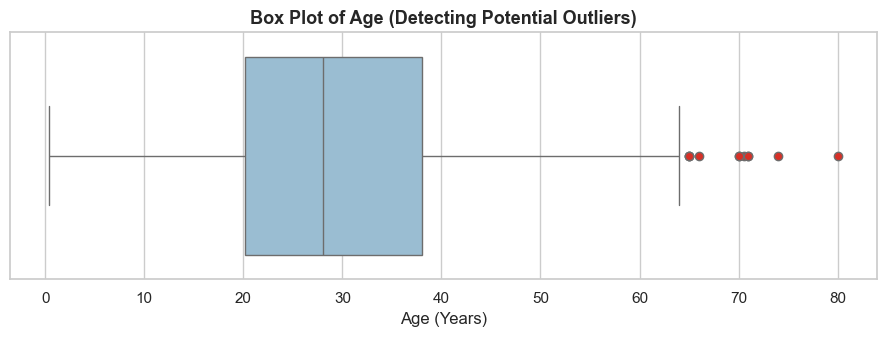

In [11]:
plt.figure(figsize=(9, 3.5))

sns.boxplot(x=df['Age'], color='#91bfdb', flierprops={'marker':'o', 'markerfacecolor':'#d73027'})

plt.title('Box Plot of Age (Detecting Potential Outliers)', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.tight_layout()
plt.show()


### Observation
The box plot highlights:
- Median passenger age is **28 years**.
- 50% of all passengers were between **20.125** and **38.0** years old.
- The upper fence is at **64.81 years**. Points beyond this (ages 65 to 80) are flagged as potential outliers. In historical context, elderly passengers on the Titanic were legitimate observations, not measurement errors.


### 3.5 Outlier Analysis on Fare

`Fare` is notoriously right-skewed. Let us calculate its fences and count how many outliers exist.


In [12]:
q1_fare = df['Fare'].quantile(0.25)
q3_fare = df['Fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
upper_fare_fence = q3_fare + 1.5 * iqr_fare

fare_outliers = df[df['Fare'] > upper_fare_fence]

print(f"Fare Q1: £{q1_fare:.2f}, Q3: £{q3_fare:.2f}, IQR: £{iqr_fare:.2f}")
print(f"Fare Upper Fence: £{upper_fare_fence:.2f}")
print(f"Number of Fare outliers: {len(fare_outliers)} out of {len(df)} ({len(fare_outliers)/len(df)*100:.1f}%)")
print(f"Max Fare recorded: £{df['Fare'].max():.2f}")


Fare Q1: £7.91, Q3: £31.00, IQR: £23.09
Fare Upper Fence: £65.63
Number of Fare outliers: 116 out of 891 (13.0%)
Max Fare recorded: £512.33


### Observation
Over **116 passengers (13.0%)** paid more than the upper fence threshold of **£66.34**. Three passengers paid an extreme maximum of **£512.33**.


### 3.6 Violin Plot

A **Violin Plot** combines a box plot with a symmetric KDE curve.
It allows us to see both the quartiles/median AND the actual probability density profile at once.


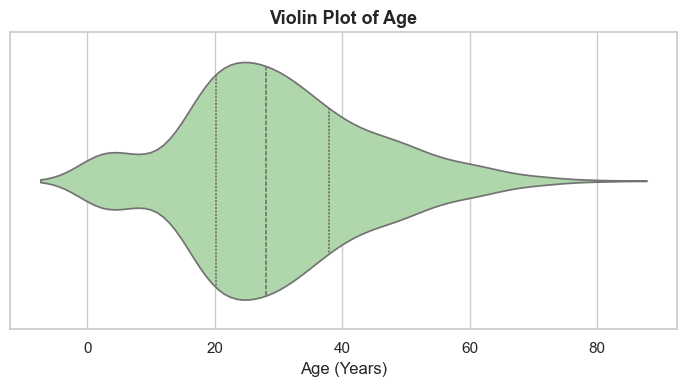

In [13]:
plt.figure(figsize=(7, 4))

sns.violinplot(x=df['Age'], color='#abdda4', inner='quartile')

plt.title('Violin Plot of Age', fontsize=13, weight='bold')
plt.xlabel('Age (Years)')
plt.tight_layout()
plt.show()


### Observation
The violin plot bulges out where data is densest (ages 20-30), tapers toward the elderly tail, and clearly shows the dashed lines for the 25th, 50th (median), and 75th percentiles.


### 3.7 Empirical Cumulative Distribution Function (ECDF)

An **ECDF** plots the proportion of data points less than or equal to a specific value $x$:
$$F(x) = \frac{\text{Number of points } \le x}{N}$$

**Why ECDF is powerful:**
1. Zero binning bias.
2. Shows every single data point.
3. Reading percentiles is effortless (e.g., find 0.80 on the Y-axis and look down to find the 80th percentile value).


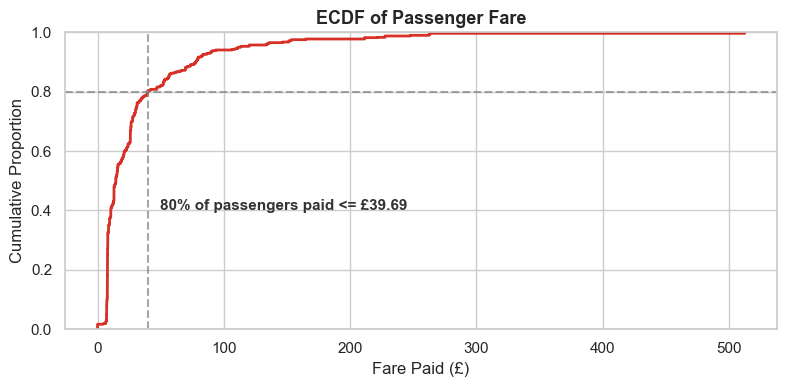

In [14]:
plt.figure(figsize=(8, 4))

sns.ecdfplot(data=df, x='Fare', color='#d73027', linewidth=2)

plt.axhline(0.80, color='gray', linestyle='--', alpha=0.7)
p80 = df['Fare'].quantile(0.80)
plt.axvline(p80, color='gray', linestyle='--', alpha=0.7)

plt.title('ECDF of Passenger Fare', fontsize=13, weight='bold')
plt.xlabel('Fare Paid (£)')
plt.ylabel('Cumulative Proportion')
plt.text(p80 + 10, 0.40, f"80% of passengers paid <= £{p80:.2f}", weight='bold', color='#333333')
plt.tight_layout()
plt.show()


### Observation
The ECDF rises steeply from £0 to ~£30, showing that 80% of all passengers paid under **£39.69**. The line then flattens across a very long tail up to £512.


### 3.8 Strip / Dot Plot

A **Strip Plot** displays the individual data points with small random jitter to prevent points from stacking directly on top of each other.


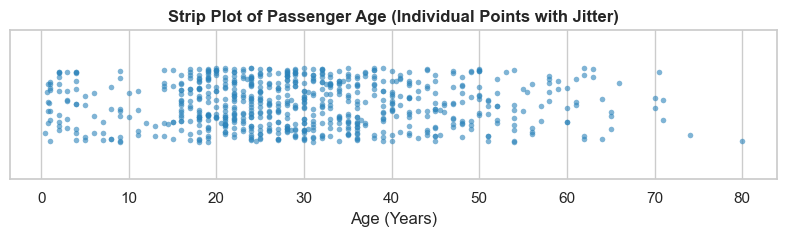

In [15]:
plt.figure(figsize=(8, 2.5))

sns.stripplot(x=df['Age'], jitter=0.25, size=4, color='#2b83ba', alpha=0.6)

plt.title('Strip Plot of Passenger Age (Individual Points with Jitter)', fontsize=12, weight='bold')
plt.xlabel('Age (Years)')
plt.tight_layout()
plt.show()


### Observation
The strip plot shows every single individual passenger record. We can see dense clustering in the 20-35 range and sparse individual points extending out to age 80.


## 4. Central Tendency & Dispersion Metrics

We now compute and compare the mathematical summary metrics:
- **Central Tendency:** Mean, Median, Mode
- **Dispersion:** Range, Variance, Standard Deviation, IQR


In [16]:
def compute_stats(series, name):
    s = series.dropna()
    mean = s.mean()
    median = s.median()
    mode = s.mode().iloc[0]
    data_range = s.max() - s.min()
    var = s.var()
    std = s.std()
    iqr = s.quantile(0.75) - s.quantile(0.25)
    skew = s.skew()
    kurt = s.kurt()
    
    return pd.Series({
        'Mean': round(mean, 2),
        'Median': round(median, 2),
        'Mode': round(mode, 2),
        'Range': round(data_range, 2),
        'Variance': round(var, 2),
        'Std Dev': round(std, 2),
        'IQR': round(iqr, 2),
        'Skewness': round(skew, 2),
        'Kurtosis': round(kurt, 2)
    }, name=name)

stats_comparison = pd.concat([compute_stats(df['Age'], 'Age'), compute_stats(df['Fare'], 'Fare')], axis=1)
stats_comparison


,Age,Fare
Mean,29.70,32.20
Median,28.00,14.45
Mode,24.00,8.05
Range,79.58,512.33
Variance,211.02,2469.44
Std Dev,14.53,49.69
IQR,17.88,23.09
Skewness,0.39,4.79
Kurtosis,0.18,33.40


### Observation
Look at the stark difference between `Age` and `Fare`:
- **`Age` is relatively symmetric:**
  - Mean (**29.70**) $\approx$ Median (**28.00**).
  - Skewness is low (**0.39**).
- **`Fare` is severely right-skewed:**
  - Mean (**£32.20**) is **more than double** the Median (**£14.45**)!
  - Skewness is very high (**4.79**).
  - Kurtosis is enormous (**33.40**), indicating extreme heavy-tail behavior.


### 4.1 Mean vs. Median: Visualizing the Skew Pull

When data is skewed, the **Mean is pulled toward the long tail**, whereas the **Median remains resistant**.


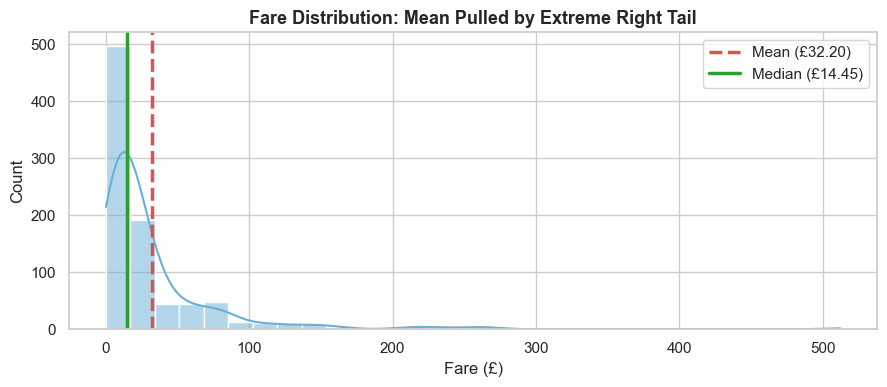

In [17]:
plt.figure(figsize=(9, 4))

sns.histplot(df['Fare'], bins=30, color='#6baed6', kde=True)

fare_mean = df['Fare'].mean()
fare_median = df['Fare'].median()

plt.axvline(fare_mean, color='#d9534f', linestyle='--', linewidth=2.5, label=f'Mean (£{fare_mean:.2f})')
plt.axvline(fare_median, color='#2ca02c', linestyle='-', linewidth=2.5, label=f'Median (£{fare_median:.2f})')

plt.title('Fare Distribution: Mean Pulled by Extreme Right Tail', fontsize=13, weight='bold')
plt.xlabel('Fare (£)')
plt.ylabel('Count')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Observation
This visual clearly shows why you should report the **Median** rather than the Mean for skewed features. The green median line (£14.45) accurately describes where 50% of passengers lie, while the red mean line (£32.20) is artificially inflated by luxury suite tickets.


### Key Takeaways
1. For categorical features, use `value_counts()` and count plots to evaluate category sizes.
2. For numerical features, always inspect both a histogram (with reasonable bin width) and a box plot (to identify outliers).
3. The $1.5 \times IQR$ rule flags potential outliers, but domain context determines whether they are erroneous or valid extreme records.
4. When skewness is high ($> 1$), the Median and IQR are far more trustworthy than the Mean and Standard Deviation.
